In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
# Load the data
df = pd.read_csv("C:/Users/kihoo/OneDrive/Desktop/Berkeley/295/project4.1.csv", encoding="latin1")

# Drop the 'Name' column and any columns with NaN values
df = df.drop(columns=['Name'])
df = df.dropna()

# Separate features and target
X = df.drop('Market Value', axis=1)
y = df['Market Value']

# Identify numeric and categorical columns
numeric_features = ['Age', 'Pace', 'Shooting', 'Passing', 'Dribbling', 'Defending', 'Physicality']
categorical_features = ['Team', 'Nationality']

# Create preprocessing steps
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False)

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create a preprocessing and model pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

# Fit and transform the data
X_processed = pipeline.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

(341, 11)

In [61]:
import keras
from keras import regularizers
from keras.layers import Dropout
from keras import backend as K
from keras.layers import BatchNormalization

# Initialize weights with values between -0.1 and 0.1
initializer = keras.initializers.RandomUniform(minval=-0.9, maxval=0.9)

model = keras.Sequential([
    keras.layers.Dense(11, activation='relu', input_shape=[X_train.shape[1]], kernel_initializer=initializer,
                       kernel_regularizer=regularizers.l2(0.01)),  # L2 regularization
    Dropout(0.2),  # Dropout layer with 20% dropout rate
    
    keras.layers.Dense(22, activation='relu', kernel_initializer=initializer, 
                       kernel_regularizer=regularizers.l2(0.01)),  # L2 regularization
    Dropout(0.2),  # Dropout layer
    
    keras.layers.Dense(11, activation='relu', kernel_initializer=initializer,
                       kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01)),  # L1 and L2 regularization
    Dropout(0.2),  # Dropout layer
    
    keras.layers.Dense(5, activation='relu', kernel_initializer=initializer,
                       kernel_regularizer=regularizers.l2(0.01)),  # L2 regularization
    Dropout(0.2),  # Dropout layer
    
    keras.layers.Dense(1, kernel_initializer=initializer)  # No regularization for the output layer
])

model.summary()

c:\Users\kihoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_37 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 22)             │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 22)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 11)             │           253 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 5)              │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 715 (2.79 KB)

 Trainable params: 715 (2.79 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
rms = keras.optimizers.RMSprop(0.020)
model.compile(loss='mean_absolute_error',optimizer=rms)

In [65]:
es = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=50,
    restore_best_weights=True,
    verbose=1)

mc = keras.callbacks.ModelCheckpoint('best_model.keras', monitor='val_loss',
                     mode='min', verbose=1, save_best_only=True)

historyData = model.fit(X_train, y_train, validation_split=0.2, epochs=200, batch_size=32, callbacks=[es, mc])

loss_hist = historyData.history['val_loss']
best_epoch = np.argmin(historyData.history['val_loss']) + 1
print('Best epoch =', best_epoch)
print('Smallest validation loss =', np.min(loss_hist))

model.save('./best_model.keras')

Epoch 1/200
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 14.8933
Epoch 1: val_loss improved from inf to 8.23663, saving model to best_model.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 13.6150 - val_loss: 8.2366
Epoch 2/200
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 8.6338
Epoch 2: val_loss improved from 8.23663 to 8.19966, saving model to best_model.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 11.7664 - val_loss: 8.1997
Epoch 3/200
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 10.3800
Epoch 3: val_loss improved from 8.19966 to 8.13244, saving model to best_model.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 12.3491 - val_loss: 8.1324
Epoch 4/200
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 15.5223
Epoch 4: val_loss improved from 8.13244 to 7.83037, saving model to best_model.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 13.1872 - val_loss: 7.8304
Epoch 5/200
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 10.1893
Epoch 5: val_loss improved from 7.83037 to 7.6

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Mean Absolute Error (MAE): 9.636980264574982


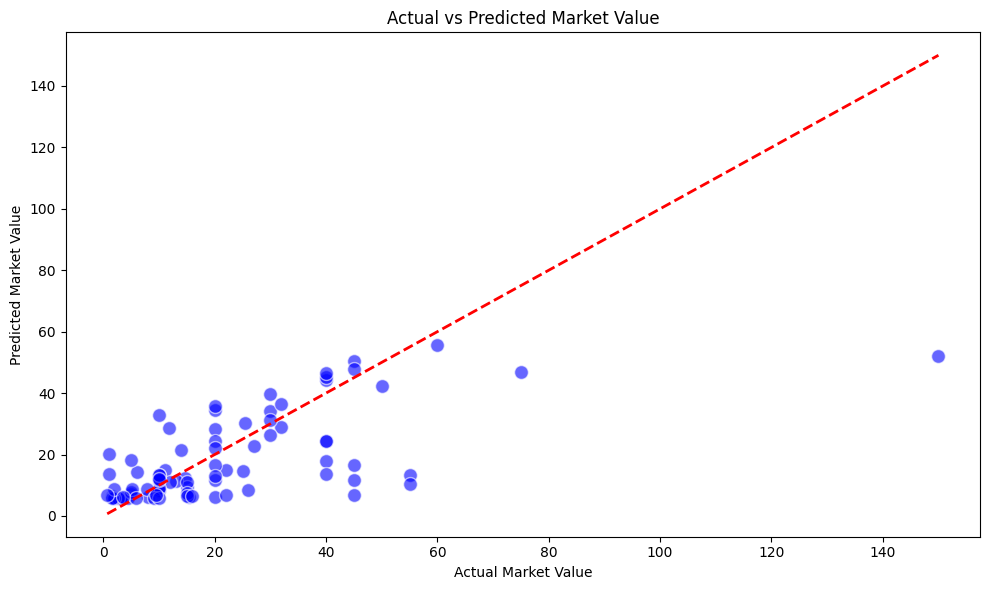

In [66]:
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# Assuming you have the test data X_test and y_test
# Get predictions for the test dataset
y_pred = model.predict(X_test)

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error (MAE): {mae}')

# Plot actual vs predicted market value
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, edgecolors='w', s=100)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Line for perfect prediction
plt.xlabel('Actual Market Value')
plt.ylabel('Predicted Market Value')
plt.title('Actual vs Predicted Market Value')
plt.tight_layout()
plt.show()
